# Example 4.2

Optimization result for y3(0):
1.3119219038455157


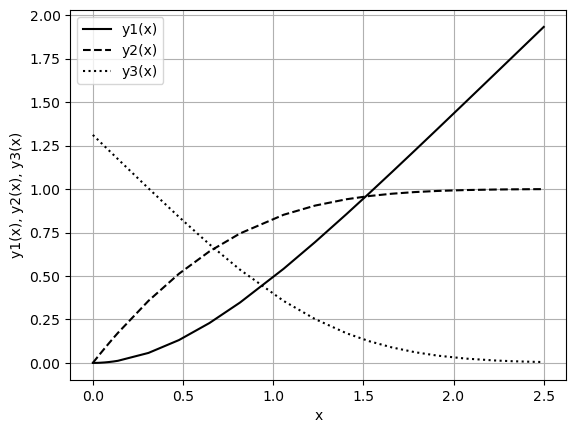

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

def System(t, y):
    """
    Function that defines the system of ODEs
    """
    yp = np.zeros(3)
    yp[0] = y[1]
    yp[1] = y[2]
    yp[2] = y[1]**2 - 1 - 2*y[0]*y[2]
    return yp

def Integrate(x):
    """
    Computation of the objective function,
    corresponding to the minimization of a boundary condition
    """
    Y0 = np.array([0.0, 0.0, x[0]])

    sol = solve_ivp(
        System,
        (0.0, 2.5),
        Y0,
        method="BDF"   # equivalent to ode23s (stiff solver)
    )

    f = (1.0 - sol.y[1, -1])**2
    return f

x0 = np.array([1.0])

result = minimize(Integrate, x0)

x_opt = result.x[0]

print("Optimization result for y3(0):")
print(x_opt)

Y0 = np.array([0.0, 0.0, x_opt])

sol = solve_ivp(
    System,
    (0.0, 2.5),
    Y0,
    method="BDF"
)

T = sol.t
Y = sol.y.T

plt.plot(T, Y[:, 0], 'k-', label='y1(x)')
plt.plot(T, Y[:, 1], 'k--', label='y2(x)')
plt.plot(T, Y[:, 2], 'k:', label='y3(x)')

plt.xlabel('x')
plt.ylabel('y1(x), y2(x), y3(x)')
plt.legend(loc='best')
plt.grid(True)

# Save figure
filename = 'Figure_4_2.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
